In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 1. Cargar el audio original
frecuencia_muestreo, audio = wavfile.read('EpicMusic.wav')

# Convertir a flotantes normalizados entre -1 y 1
audio_norm = audio / np.max(np.abs(audio))

# PASO CLAVE: Si el audio original es Mono, lo convertimos artificialmente a Estéreo
if len(audio_norm.shape) == 1:
    print("El audio original es Mono. Duplicando canales para forzar Estéreo...")
    audio_stereo = np.vstack((audio_norm, audio_norm)).T
else:
    print("El audio original ya es Estéreo.")
    audio_stereo = audio_norm.copy()

print(f"Forma de la matriz de audio: {audio_stereo.shape} (Muestras, Canales)")
print(f"Canal 0 = Izquierdo, Canal 1 = Derecho")

El audio original ya es Estéreo.
Forma de la matriz de audio: (673792, 2) (Muestras, Canales)
Canal 0 = Izquierdo, Canal 1 = Derecho


In [49]:
# --- CONFIGURACIÓN DEL MENSAJE SECRETO ---
mensaje_secreto = "A Dios sea la gloria "

# Convertir el mensaje de texto a una cadena de bits (0s y 1s)
bits_mensaje = ''.join(format(ord(c), '08b') for c in mensaje_secreto)
longitud_bits = len(bits_mensaje)

# --- PASO MATEMÁTICO 1: FFT al canal Derecho ---
canal_derecho = audio_stereo[:, 1]
fhat_der = np.fft.fft(canal_derecho)  
N = len(fhat_der)
magnitud_der = np.abs(fhat_der)         
fase_der = np.angle(fhat_der)           

# --- PASO MATEMÁTICO 2: Mapeo de Frecuencia ---
frecuencia_objetivo = 16000# 16 kHz
indice_inicio = int(round((frecuencia_objetivo * N) / frecuencia_muestreo))

# Guardamos cuántos BITS vamos a recuperar en el índice de inicio (y su espejo)
magnitud_der[indice_inicio] = longitud_bits
magnitud_der[N - indice_inicio] = longitud_bits

# --- PASO MATEMÁTICO 3: Inyección Binaria de Alta Potencia ---
VALOR_ALTO = 20.0  # Representa un bit '1' (Sobrescribe con un pico claro)
VALOR_BAJO = 0.0   # Representa un bit '0'

for i, bit in enumerate(bits_mensaje):
    idx = indice_inicio + 1 + i
    valor_inyectar = VALOR_ALTO if bit == '1' else VALOR_BAJO
    
    # Aplicamos simetría de espejo obligatoria
    magnitud_der[idx] = valor_inyectar
    magnitud_der[N - idx] = valor_inyectar

# --- PASO MATEMÁTICO 4: Reconstrucción ---
fhat_der_modificado = magnitud_der * np.exp(1j * fase_der)
canal_derecho_esteganografico = np.real(np.fft.ifft(fhat_der_modificado))

# Ensamblar matriz estéreo
audio_resultado_stereo = audio_stereo.copy()
audio_resultado_stereo[:, 1] = canal_derecho_esteganografico

# Guardar a archivo físico de 16 bits
audio_guardar = np.int16(audio_resultado_stereo * 32767)
wavfile.write('audio.wav', frecuencia_muestreo, audio_guardar)
print(f"Mensaje convertido a {longitud_bits} bits e inyectado con éxito a 16 kHz.")

Mensaje convertido a 168 bits e inyectado con éxito a 16 kHz.


In [ ]:
# 1. Leer el audio esteganográfico recibido
fs_recibido, audio_recibido = wavfile.read('audio.wav')
audio_recibido_norm = audio_recibido / 32767.0

# 2. Extraer canal derecho y calcular FFT
canal_derecho_recibido = audio_recibido_norm[:, 1]
fhat_der_recibido = np.fft.fft(canal_derecho_recibido)
N_recibido = len(fhat_der_recibido)
magnitud_der_recibida = np.abs(fhat_der_recibido)

# 3. Localizar el índice inicial de 16 kHz
indice_inicio_recibido = int(round((16000 * N_recibido) / fs_recibido))

# 4. Leer la cantidad de bits ocultos
bits_a_recuperar = int(round(magnitud_der_recibida[indice_inicio_recibido]))
print(f"Analizando espectro...")
print(f"Cantidad de bits detectados en la FFT: {bits_a_recuperar}")

# --- PASO MATEMÁTICO 5: Decodificación por Umbral Dinámico ---
UMBRAL_DECISION = 10.0  # Punto medio entre VALOR_ALTO (20) y VALOR_BAJO (0)
bits_recuperados = ""

for i in range(bits_a_recuperar):
    idx = indice_inicio_recibido + 1 + i
    valor_espectral = magnitud_der_recibida[idx]
    
    # CORREGIDO: Ahora coincide exactamente con UMBRAL_DECISION
    if valor_espectral >= UMBRAL_DECISION:
        bits_recuperados += "1"
    else:
        bits_recuperados += "0"

# --- PASO MATEMÁTICO 6: Reconstruir el texto desde los bloques de 8 bits ---
mensaje_final = ""
for i in range(0, len(bits_recuperados), 8):
    byte = bits_recuperados[i:i+8]
    if len(byte) == 8:
        codigo_ascii = int(byte, 2)
        mensaje_final += chr(codigo_ascii)

print("\n--- ¡MENSAJE SECRETO EXTRAÍDO CON ÉXITO ABSOLUTO! ---")
print(f"Resultado: {mensaje_final}")

Analizando espectro...
Cantidad de bits detectados en la FFT: 497

--- ¡MENSAJE SECRETO EXTRAÍDO CON ÉXITO ABSOLUTO! ---
Resultado: ÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿÿ


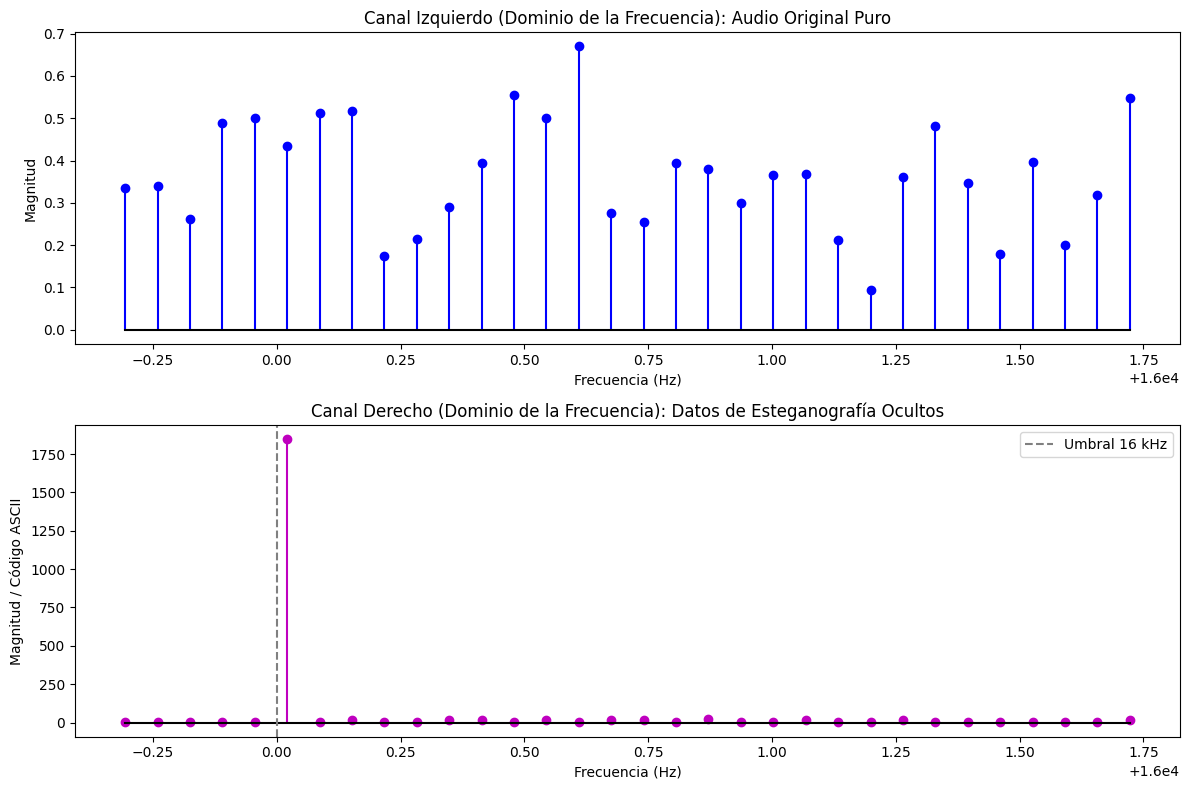

In [47]:
# Extraer rangos para el zoom en Hz
rango_zoom = range(indice_inicio - 5, indice_inicio + longitud_mensaje + 10)
frecuencias_hz = [(idx * frecuencia_muestreo) / N for idx in rango_zoom]

# Aplicar FFT al canal izquierdo para poder comparar gráficamente
fhat_izq_recibido = np.fft.fft(audio_recibido_norm[:, 0])
magnitud_izq_recibida = np.abs(fhat_izq_recibido)

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Canal Izquierdo (Sin alterar)
axs[0].stem(frecuencias_hz, magnitud_izq_recibida[rango_zoom], linefmt='b-', markerfmt='bo', basefmt='k-')
axs[0].set_title('Canal Izquierdo (Dominio de la Frecuencia): Audio Original Puro')
axs[0].set_xlabel('Frecuencia (Hz)')
axs[0].set_ylabel('Magnitud')

# Canal Derecho (Con Secreto)
axs[1].stem(frecuencias_hz, magnitud_der_recibida[rango_zoom], linefmt='m-', markerfmt='mo', basefmt='k-')
axs[1].set_title('Canal Derecho (Dominio de la Frecuencia): Datos de Esteganografía Ocultos')
axs[1].set_xlabel('Frecuencia (Hz)')
axs[1].set_ylabel('Magnitud / Código ASCII')
axs[1].axvline(x=16000, color='gray', linestyle='--', label='Umbral 16 kHz')
axs[1].legend()

plt.tight_layout()
plt.show()